In [1]:
import os
import numpy as np
import nibabel as nib

In [2]:
def compute_isotropic_spacing_per_dimension(voxel_spacing):
    # Calculate the isotropic spacing using the cube root of the volume
    isotropic_value = np.cbrt(np.prod(voxel_spacing))
    
    # Round the values to 2 decimal places and return them
    return tuple(round(isotropic_value, 2) for _ in range(3))

In [14]:
def compute_image_and_voxel_sizes(image_paths):
    image_shapes = []
    voxel_sizes = []

    for img_path in image_paths:
        if os.path.exists(img_path):
            img = nib.load(img_path)
            image_shapes.append(img.shape)
            voxel_sizes.append(img.header.get_zooms()[:3])
        else:
            print(f"Warning: {img_path} not found, skipping.")

    if not image_shapes or not voxel_sizes:
        raise ValueError("No valid images found. Check the directory structure.")

    image_shapes = np.array(image_shapes)
    voxel_sizes = np.array(voxel_sizes)
    median_voxel = tuple(np.round(np.median(voxel_sizes, axis=0), 2))
    iso_volum_voxel = compute_isotropic_spacing_per_dimension(median_voxel)

    # Compute statistics
    stats = {
        "median_image_size": tuple(np.median(image_shapes, axis=0).astype(int)),
        "mean_image_size": tuple(np.mean(image_shapes, axis=0).astype(int)),
        "75_quartile_size": tuple(np.percentile(image_shapes, 75, axis=0).astype(int)),
        "25_quartile_size": tuple(np.percentile(image_shapes, 25, axis=0).astype(int)),
        "median_voxel": median_voxel,
        "mean_voxel": tuple(np.round(np.mean(voxel_sizes, axis=0), 2)),
        "isotropic_volume_voxel": iso_volum_voxel,  # Geometric mean for isotropic
        "isotropic_voxel": (1.0, 1.0, 1.0),
    }

    return stats

In [29]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
import monai
import numpy as np
import re
import torch

def natural_key(string_):
    return [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', string_)]

# Step 1: Get image paths and labels
def get_image_paths_and_labels(data_path, labels_path):
    directory_names = os.listdir(data_path)
    directory_path = sorted(directory_names, key=natural_key)
    image_name = "/image.nii.gz"
    segmentation_name = "/segmentation.nii.gz"
    comp_image_file = [s + image_name for s in directory_path]
    comp_segmentation_file = [s + segmentation_name for s in directory_path]
    images_path = [os.sep.join([data_path, f]) for f in comp_image_file]
    segmentation_path = [os.sep.join([data_path, f]) for f in comp_segmentation_file]

    labels_csv = pd.read_csv(labels_path)
    labels_csv.replace(-1, 1, inplace=True)
    labels = labels_csv['Diagnosis_binary'].to_numpy()

    # Ensure the number of images and labels match
    assert len(images_path) == len(labels), "Number of images and labels must match."

    # Map image paths to IDs
    image_id_mapping = {img: os.path.basename(os.path.dirname(img)) for img in images_path}
    
    return images_path, labels, segmentation_path, image_id_mapping

# Data Preparation
def prepare_data(images_path, labels):
   # Split the data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(images_path, labels, test_size=0.2, random_state=42)

    # Print some information to check the split
    print(f"Number of training images: {len(X_train)}")
    # Print the test indices
    print("Test images:", X_test)
    print(f"Number of test images: {len(X_test)}")
    print(f"Number of traini ng labels: {len(y_train)}")
    print(f"Number of test labels: {len(y_test)}")

    return X_train, y_train, X_test, y_test

In [30]:
import os
# Prepare the data
#data_path = os.path.join("..", "..", "..", "BigR", "WORCDatabase", "Lipo", "worc") # Windows
#labels_path = os.path.join("..", "..", "..", "BigR", "WORCDatabase","clinical_lipo.csv") # Windows

data_path = os.path.join("/home", "noviedoacosta", "Desktop", "worc") # Linux
segmentation_path = os.path.join("/home", "noviedoacosta", "Desktop", "worc") # Linux
labels_path = os.path.join(".", "labels", "Lipo.csv") # Linux

image_path, labels, segmentation_path, image_id_mapping = get_image_paths_and_labels(data_path, labels_path)
X_train, y_train, X_test, y_test = prepare_data(image_path, labels)
stats = compute_image_and_voxel_sizes(image_path)
print(stats)

Number of training images: 92
Test images: ['/home/noviedoacosta/Desktop/worc/Lipo-082/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-005/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-041/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-070/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-011/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-046/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-071/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-067/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-048/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-012/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-101/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-037/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-085/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-114/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-019/image.nii.gz', '/home/noviedoacosta/Desktop/worc/Lipo-001/image.nii.gz', '/home/noviedoacosta/Desktop

In [16]:
import monai

from monai.transforms import (
    Compose,
    LoadImage,
    LoadImaged,
    EnsureChannelFirst,
    EnsureChannelFirstd,
    RandRotate,
    RandZoom,
    RandAffine,
    RandGaussianNoise,
    RandScaleIntensity,
    RandAdjustContrast,
    RandFlip,
    RandRicianNoise,
    RandGaussianSmooth,
    Resize,
    Spacing,
)


In [9]:
median_voxel = stats['median_voxel']
mean_voxel = stats['mean_voxel']
isotropic_voxel = stats['isotropic_voxel']
iso_volumetric_voxel = stats['isotropic_volume_voxel']

In [10]:
def TestTransform(target_spacing):
    """
    :return: A preprocessing pipeline for the validation samples.
    """

     # Define MONAI transforms
    transforms = Compose([
        LoadImage(image_only=True),  # Load NIfTI images
        EnsureChannelFirst(),  # Ensure channels are first (for compatibility)
        Spacing(pixdim=target_spacing, mode="bilinear"),  # Resample to target spacing
    ])
    return transforms


In [11]:
train_set = monai.data.ArrayDataset(img=X_train, labels=y_train, img_transform=TestTransform(median_voxel))    

In [12]:
def get_dimension_sizes(dataset):
    # Lists to store image sizes
    heights = []
    widths = []
    depths = []

    # Iterate through dataset and /home", "noviedoacosta", "Desktop", "BIGR", "preprocessing", "test", "collect image shapes
    for img, _ in dataset:
        if isinstance(img, torch.Tensor):
            img = img.numpy()  # Convert to numpy if it's a tensor
        _, height, width, depth = img.shape  # Assuming channel-first format (C, H, W, D)
        heights.append(height)
        widths.append(width)
        depths.append(depth)
    
    return heights, widths, depths
    

In [13]:
def calculate_statistics(train_set):

    heights, widths, depths = get_dimension_sizes(train_set)

    # Compute statistics
    stats = {
        "median": (
            round(np.median(heights), 2),
            round(np.median(widths), 2),
            round(np.median(depths), 2)
        ),
        "mean": (
            round(np.mean(heights), 2),
            round(np.mean(widths), 2),
            round(np.mean(depths), 2)
        ),
        "75th_quartile": (
            round(np.percentile(heights, 75), 2),
            round(np.percentile(widths, 75), 2),
            round(np.percentile(depths, 75), 2)
        )
    }

    return stats

In [70]:
# Load segmentation mask and calculate the shape. 
# If segmentation mask if higher than the 75th percentile, or lower than the 25th percentile,
# then the segmentation path is saved in a variable threshold_idx

def get_threshold_idx(segmentation_path, stats):
    threshold_idx = []
    max_quartile = stats['75_quartile_size']
    min_quartile = stats['25_quartile_size']
    for idx, img in enumerate(segmentation_path):
        img = nib.load(img)
        dimensions = img.shape
        # Combine the conditions in one readable check
        if all(min_quartile[i] < var < max_quartile[i] for i, var in enumerate((dimensions))):
            print("All conditions are met!")
            #print("All conditions are met!")
        else:
            print("Conditions are not met.")
            print(dimensions)
            print(min_quartile[0])
            threshold_idx.append(idx)
        #if height > np.percentile(stats[0], 75) or height < np.percentile(heights, 25):
        #    threshold_idx.append(idx)
        break
    return threshold_idx    

In [71]:
# Get only the second and third key-value pairs
selected_stats = dict(list(stats.items())[2:4])
print(selected_stats['75_quartile_size'])
print(selected_stats['25_quartile_size'])
ids = get_threshold_idx(segmentation_path, selected_stats)
print(ids)

(512, 512, 40)
(384, 344, 26)
Conditions are not met.
(256, 224, 33)
384
[0]


In [ ]:
stats = {(1, 2, 3), (4, 5, 6)}

# Determine first (smallest) and second (largest) tuples dynamically
first, second = sorted(stats)

# Variables to check
height = 2  # example value
width = 3   # example value
slice = 5   # example value




In [18]:
import tqdm
# Get all images that are higher than the `75th_quartile` in every dimension
img_IDs = [re.search(r"Lipo-(\d+)", path).group(1) for path in image_path]

threshold = list() 
threshold_ids = list()
quartile_cut = stats["75th_quartile"]

for mask_file in tqdm(image_path):
    print(mask_file[5:13])
    # match the mask file to the original image
    if mask_file[5:13] in img_IDs:
        index = img_IDs.index(mask_file[5:13])
        
        seg = nib.load(new_path + '/' + mask_file + "/" + segmentation_name) # load segmentation
        
        seg_data = seg.get_fdata()
        sx, sy, sz = seg_data.shape
        if (sx > x_75) or (sy > y_75) or (sz > z_75) or (sx < 50) or (sy < 50) or (sz < 50):
            print(sx, sy, sz)
            threshold.append(new_path + '/' + mask_file + "/" + segmentation_name)
            threshold_ids.append(mask_file)

['001',
 '002',
 '003',
 '004',
 '005',
 '006',
 '007',
 '008',
 '009',
 '010',
 '011',
 '012',
 '013',
 '014',
 '015',
 '016',
 '017',
 '018',
 '019',
 '020',
 '021',
 '022',
 '023',
 '024',
 '025',
 '026',
 '027',
 '028',
 '029',
 '030',
 '031',
 '032',
 '033',
 '034',
 '035',
 '036',
 '037',
 '038',
 '039',
 '040',
 '041',
 '042',
 '043',
 '044',
 '045',
 '046',
 '047',
 '048',
 '049',
 '050',
 '051',
 '052',
 '053',
 '054',
 '055',
 '056',
 '057',
 '058',
 '059',
 '060',
 '061',
 '062',
 '063',
 '064',
 '065',
 '066',
 '067',
 '068',
 '069',
 '070',
 '071',
 '072',
 '073',
 '074',
 '075',
 '076',
 '077',
 '078',
 '079',
 '080',
 '081',
 '082',
 '083',
 '084',
 '085',
 '086',
 '087',
 '088',
 '089',
 '090',
 '091',
 '092',
 '093',
 '094',
 '095',
 '096',
 '097',
 '098',
 '099',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115']

Apply the resample and the cropping of the images

In [ ]:
def bbox_crop():
    

In [15]:
# create a custom crop transform

from monai.transforms import MapTransform

class CustomCrop(MapTransform):
    def __init__(self, keys, crop_size):
        super().__init__(keys)
        self.crop_size = crop_size
    
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = self.bbox_crop(d[key], self.crop_size)
        return d

Plots to check after resampling

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_dimension(sizes, dimension_name, color):
    """
    Plots a bar chart for the given dimension sizes with median, mean, and 75% percentile lines.

    Parameters:
        sizes (list): The sizes of the images in the given dimension.
        dimension_name (str): The name of the dimension (Height, Width, Depth).
        color (str): The color for the bar plot.
    """
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(sizes)), sizes, color=color, alpha=0.6, label=f"{dimension_name} Sizes")

    # Calculate statistics
    median_value = np.median(sizes)
    mean_value = np.mean(sizes)
    percentile_75 = np.percentile(sizes, 75)

    # Plot lines for median, mean, and 75% quartile
    plt.axhline(median_value, color='r', linestyle='--', label=f"Median: {median_value:.2f}")
    plt.axhline(mean_value, color='g', linestyle='-.', label=f"Mean: {mean_value:.2f}")
    plt.axhline(percentile_75, color='b', linestyle=':', label=f"75th Percentile: {percentile_75:.2f}")

    plt.xlabel("Image Index")
    plt.ylabel(f"{dimension_name} (voxels)")
    plt.title(f"Image {dimension_name}s")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_image_sizes_with_stats(dataset):
    """
    Plots bar charts for the sizes of images in each dimension (Height, Width, Depth) after transformation.

    Parameters:
        dataset (monai.data.ArrayDataset): The dataset containing transformed images.
    """
    # Lists to store image sizes
    heights = []
    widths = []
    depths = []

    # Iterate through dataset and collect image shapes
    for img, _ in dataset:
        if isinstance(img, torch.Tensor):
            img = img.numpy()  # Convert to numpy if it's a tensor
        _, height, width, depth = img.shape  # Assuming channel-first format (C, H, W, D)
        heights.append(height)
        widths.append(width)
        depths.append(depth)

    # Plot for each dimension
    plot_dimension(heights, "Height", "blue")
    plot_dimension(widths, "Width", "green")
    plot_dimension(depths, "Depth", "red")

# Example usage
# plot_image_sizes_with_stats(train_set)


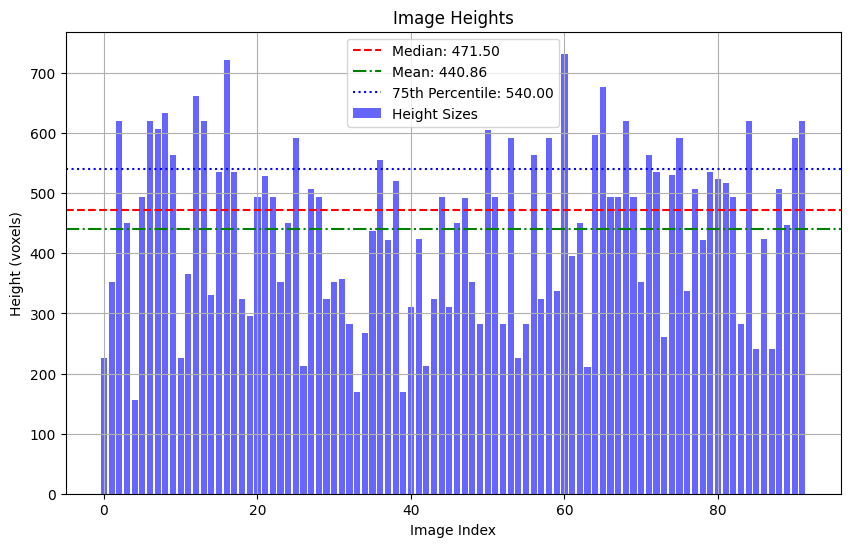

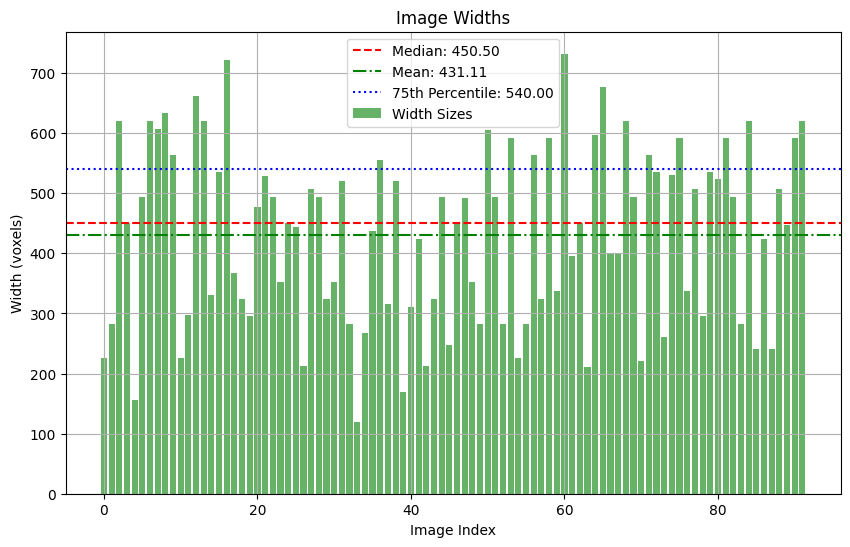

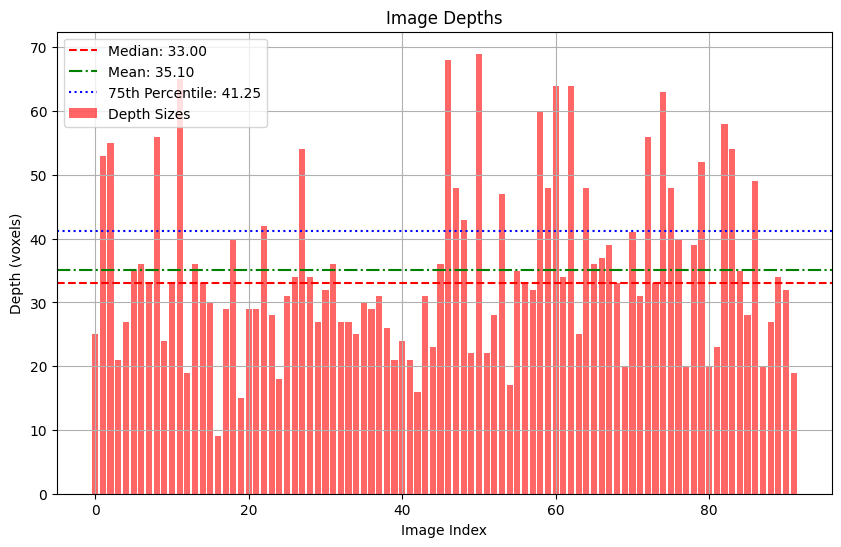

In [51]:
plot_image_sizes_with_stats(train_set)